In [ ]:
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[1]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import xr_utils
from analysis.ou_tuning.contour_intersect import contour_intersections

In [11]:
dirpath_self = Path().resolve()
dirpath_res_base = dirpath_root / 'exp_results'

exp_group = dirpath_self.name
exp_name = 'pv'
exp_name_sub = 'exp_ou_nmean_10_nstd_10'

# Load batch result
dirpath_res = (dirpath_res_base / exp_group / exp_name
               / exp_name_sub / 'combined')
fpath_res = dirpath_res / 'rates_cvs_all.nc'
X = xr.load_dataset(fpath_res)
X

<xarray.Dataset> Size: 20kB
Dimensions:      (ou_mean_ind: 10, ou_std_ind: 10, pop: 6)
Coordinates:
  * ou_mean_ind  (ou_mean_ind) int32 40B 0 1 2 3 4 5 6 7 8 9
  * ou_std_ind   (ou_std_ind) int32 40B 0 1 2 3 4 5 6 7 8 9
  * pop          (pop) object 48B 'PV2' 'PV3' 'PV4' 'PV5A' 'PV5B' 'PV6'
Data variables:
    rate         (pop, ou_mean_ind, ou_std_ind) float64 5kB 0.0 0.0 ... 175.7
    cv           (pop, ou_mean_ind, ou_std_ind) float64 5kB nan nan ... 1.654
    v_med_max    (pop, ou_mean_ind, ou_std_ind) float64 5kB -243.2 ... -24.32
    v_med_min    (pop, ou_mean_ind, ou_std_ind) float64 5kB -267.8 ... -185.7
    ou_mean      (pop, ou_mean_ind) float64 480B -0.06 -0.05 ... 0.02889 0.04
    ou_std       (pop, ou_std_ind) float64 480B 0.0 0.004444 ... 0.03556 0.04

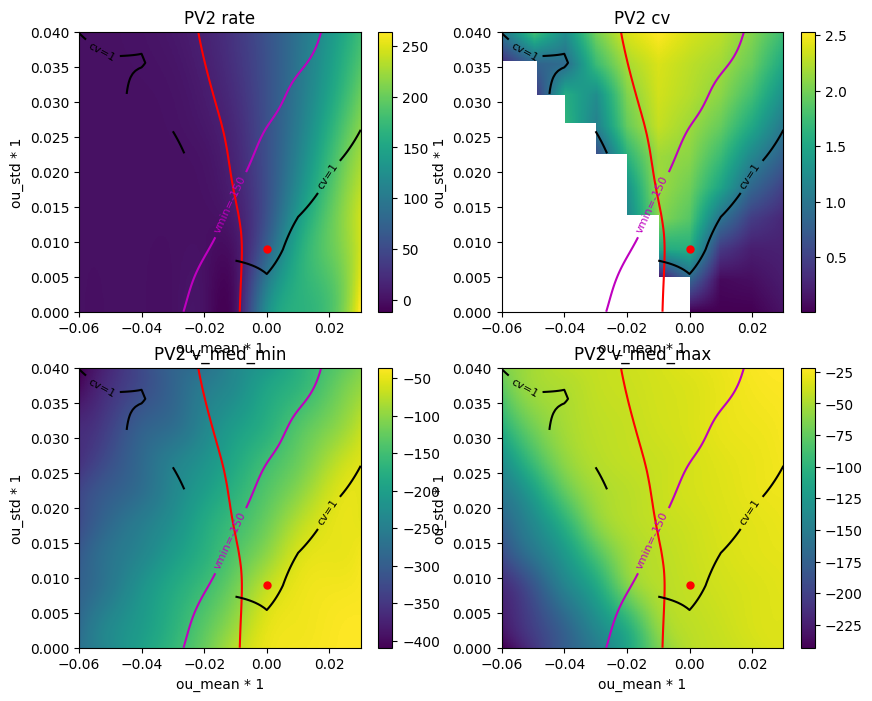

In [ ]:
pop = 'PV2'

# Load target rate
fpath_target = dirpath_self / exp_name / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')
r0 = df.loc[pop]['target_rate']

#print(f'r0 = {r0}')

vars = ['rate', 'cv', 'v_med_min', 'v_med_max']
D = {}

# Extract variables, assign (ou_mean, ou_std) coords
for v in vars:
    X_ = X[v].sel(pop=pop)
    X_ = X_.rename(ou_mean_ind='ou_mean', ou_std_ind='ou_std')
    X_ = X_.assign_coords(
        ou_mean=X['ou_mean'].sel(pop=pop).values,
        ou_std=X['ou_std'].sel(pop=pop).values
    )
    D[v] = X_.T

# Upsample data
sz_new = 100
ou_mean = D['rate'].ou_mean.values
ou_std = D['rate'].ou_std.values
ou_mean_new = np.linspace(ou_mean.min(), ou_mean.max(), sz_new)
ou_std_new = np.linspace(ou_std.min(), ou_std.max(), sz_new)
for v, X_ in D.items():
    try:
        D[v] = X_.interp(ou_mean=ou_mean_new, ou_std=ou_std_new, method='cubic')
    except:
        D[v] = X_.interp(ou_mean=ou_mean_new, ou_std=ou_std_new, method='linear')

# Plot 2-d maps of r, cv, and v stats
fig = plt.figure(figsize=(10,8))
axes = []
for n, (v, X_) in enumerate(D.items()):
    ax = plt.subplot(2, 2, n + 1)
    axes.append(ax)
    xr_utils.plot_xr(X_, show_ax_names=True)
    cc = xr_utils.plot_xr_contour(D['rate'], '', [r0], colors=['r'])
    xr_utils.plot_xr_contour(D['cv'], 'cv', [1], colors=['k'])
    xr_utils.plot_xr_contour(D['v_med_min'], 'vmin', [-150], colors=['m'])
    plt.title(f'{pop} {v}')


# Selected point
ou_mean_sel = -0.0

# Find and plot the selected point
if True:
    c = cc.allsegs[0][-1]
    ind = (np.abs(c[:, 0] - ou_mean_sel)).argmin()
    ou_std_sel = c[ind, 1]
    ou_std_sel = np.round(ou_std_sel, 4)
    #print(f'"ou_mean": {ou_mean_sel},')
    #print(f'"ou_std": {ou_std_sel}')
    for ax in axes:
        ax.plot(ou_mean_sel, ou_std_sel, 'r.', markersize=10)

# Print the metrics at the selected point
cc = {'ou_mean': ou_mean_sel, 'ou_std': float(ou_std_sel)}
for v, X_ in D.items():
    x = X_.interp(**cc).values
    #print(f'{v} = {x:.03f}')


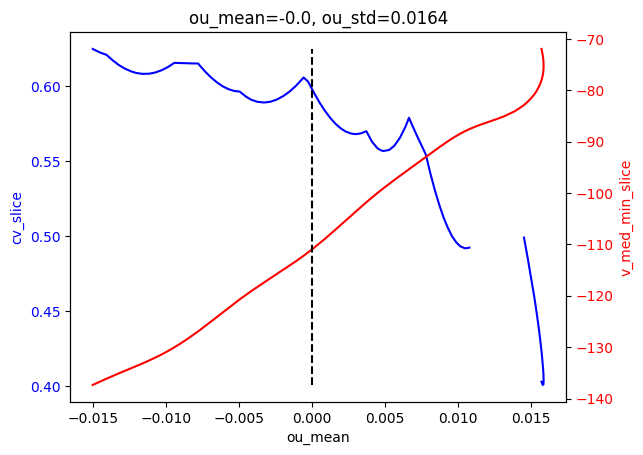

In [19]:
# Extract slice along the target rate contour for each var
Ds = {}
for v, X_ in D.items():
    Ds[f'{v}_slice'] = X_.interp(
        ou_std=('points', c[:, 1]),
        ou_mean=('points', c[:, 0])
    )

fig, ax1 = plt.subplots()

# Plot Ds['cv_slice'] on the first y-axis
ax1.plot(Ds['cv_slice'].ou_mean, Ds['cv_slice'], 'b-', label='cv_slice')
ax1.set_xlabel('ou_mean')
ax1.set_ylabel('cv_slice', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis for Ds['v_med_min_slice']
ax2 = ax1.twinx()
ax2.plot(Ds['v_med_min_slice'].ou_mean, Ds['v_med_min_slice'], 'r-', label='v_med_min_slice')
ax2.set_ylabel('v_med_min_slice', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Plot a vertical line at ou_mean_sel on ax1
ax2.plot([ou_mean_sel, ou_mean_sel], [Ds['v_med_min_slice'].min(), Ds['v_med_min_slice'].max()], 'k--')

# Add a title
plt.title(f'ou_mean={ou_mean_sel:.04}, ou_std={ou_std_sel:.04}')

# Show the plot
plt.show()

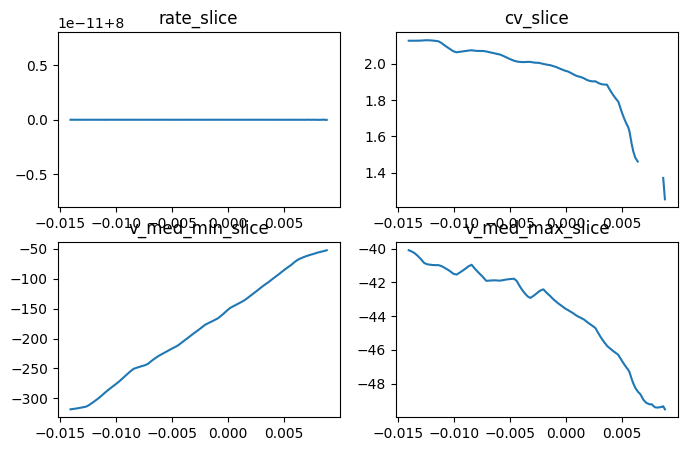

In [162]:
# Plot the slices
plt.figure(figsize=(8, 5))
for n, (v, X_) in enumerate(Ds.items()):
    plt.subplot(2, 2, n + 1)
    plt.plot(X_.ou_mean, X_)
    plt.title(v)

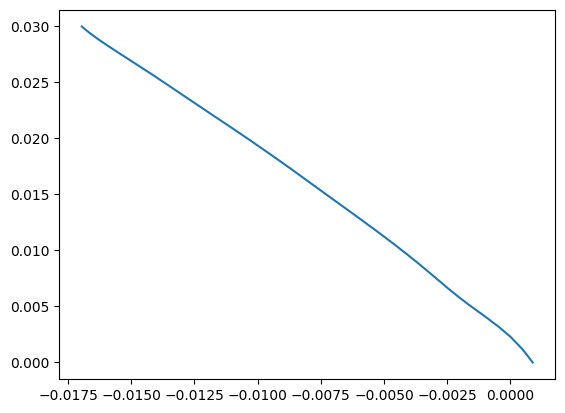

In [133]:
# Test rate contour
plt.figure()
for c in cc.allsegs[0]:
    plt.plot(c[:, 0], c[:, 1])

In [8]:
import numpy as np

par = {
    't0': 1500,
    'period': 200,
    'jitter': 10,
    'width': 50,
    'n_pulses': 1000,
    'rates': 10,
    'pop': 'TCM',
    'weight': 1,
    'rand_type': 'norm',
    'ncells': 500,
    'convergence': 1
}

Tsim = 5000
dt = 0.1

t0, T, jit = par['t0'], par['period'], par['jitter']

# If pulse rate is a scalar - repeat it for each pulse
if np.isscalar(par['rates']):
    par['rates'] = [par['rates']] * par['n_pulses']

# Generate pulse timings
tpulse = [t0]
for _ in range(1, par['n_pulses']):
    if par['rand_type'] == 'uni':
        t = tpulse[-1] + T + np.random.uniform(-jit, jit)
    elif par['rand_type'] == 'norm':
        t = tpulse[-1] + np.random.normal(T, jit)
    else:
        raise ValueError('Unknown rand_type for pulse sequence: %s' % par['rand_type'])
    tpulse.append(t)
tpulse = np.asarray(tpulse)

# Discard pulses beyond Tsim
n_pulses = len(tpulse < Tsim)
par['n_pulses'] = n_pulses
par['tpulse'] = tpulse[:n_pulses].tolist()
par['rates'] = par['rates'][:n_pulses]

# Time bins
tvec = np.arange(0, Tsim, dt)
Nt = len(tvec)

# Generare firing rate timecourse
rvec = np.zeros(Nt)
for n, tp in enumerate(tpulse):
    mask = (tp <= tvec) & (tvec < (tp + par['width']))
    rvec[mask] = par['rates'][n]

# Generate Poisson spikes
ncells = par['ncells']
S = (np.random.rand(ncells, Nt) < (rvec * dt / 1000))
spike_times = [tvec[np.argwhere(S[n, :])].ravel().tolist()
                for n in range(ncells)]

Text(0.5, 0, 'Time, ms')

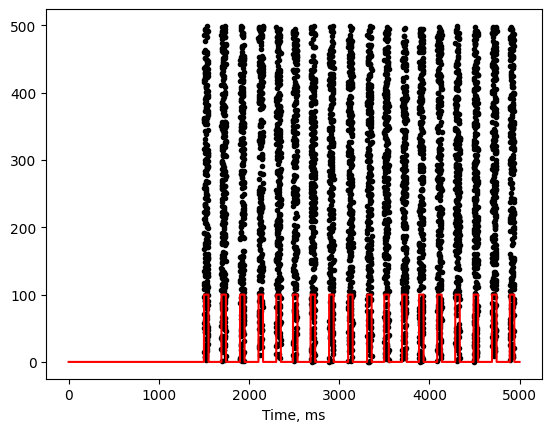

In [9]:
plt.figure()
for n in range(par['ncells']):
    st = spike_times[n]
    plt.plot(st, [n] * len(st), 'k.')
plt.plot(tvec, rvec * 10, 'r')
plt.xlabel('Time, ms')

Text(0.5, 0, 'Time, ms')

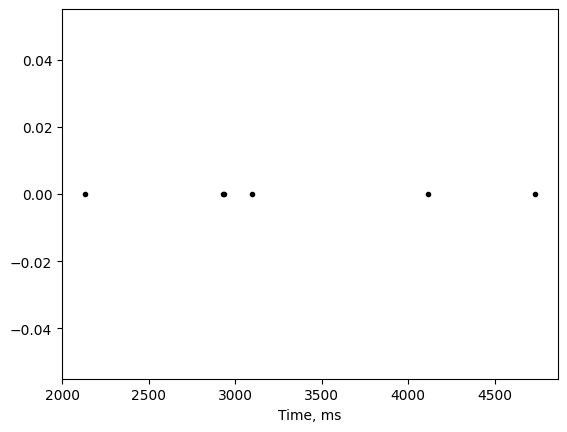

In [73]:
import json
from pathlib import Path
import pickle

import model_tuner.data_proc.netpyne_res_parse_utils as utils


dirpath_base = Path('/ddn/niknovikov19/repo/A1_OUinp/exp_results'
                    '/single_i_ou_unconn_state_1_nosub/thal_wmult_0.1_pulses'
                    '/sim_5s_pulses_TCM_50_200_jit_10_norm_w_1_r_10_n_1_c_1')
exp_name = 'thal_wmult_0.1_pulses'

# Spike times from netParams
fpath_par = dirpath_base / f'{exp_name}_netParams.json'
#fpath_par = dirpath_base / f'{exp_name}_params.json'
with open(fpath_par, 'r') as fid:
    par = json.load(fid)
S0 = par['net']['params']['popParams']['PulseSeq']['spkTimes']

# Spike times from pkl
fpath_pkl = dirpath_base / f'{exp_name}_data.pkl'
with open(fpath_pkl, 'rb') as fid:
    sim_res = pickle.load(fid)
S = utils.get_pop_spikes(
    sim_res, 'PulseSeq', combine_cells=False, ms=True)

plt.figure()
for n, st in enumerate(S):
    plt.plot(st, [n] * len(st), 'k.')
#plt.plot(tvec, rvec * 10, 'r')
plt.xlabel('Time, ms')

In [74]:
ss0 = np.sort(np.concatenate(S0))
ss = np.sort(np.concatenate(S))

#pulse_num = 3
#th = 1500 + 200 * pulse_num + 50
th = 0
nprint = None
print(ss0[ss0 > th][:nprint])
print(ss[ss > th][:nprint])

[1923.35 2130.65 2169.85 2364.6  2584.25 2748.1  3166.05 3794.9  3975.95
 4406.7  4742.95 4770.8  4947.6 ]
[2130.05 2929.25 2936.25 3099.75 4115.   4736.4 ]


In [49]:
ncell = len(S)
k = 0
st0 = np.array([float(S0[n][k]) for n in range(ncells)])
st = np.array([float(S[n][k]) for n in range(ncells)])

idx0 = np.argsort(st0)
idx = np.argsort(st)

print(st0[idx0][:20])
print(st[idx][:20])

print(st0[idx0][4])
print(st[idx][4])

[1500.35 1500.4  1500.5  1500.5  1500.6  1500.7  1500.8  1500.85 1500.9
 1501.05 1501.9  1502.1  1502.85 1502.85 1502.95 1503.05 1503.1  1503.25
 1503.3  1503.65]
[1500.4  1500.5  1500.5  1500.55 1500.6  1500.8  1500.9  1501.05 1501.15
 1501.3  1501.55 1502.1  1502.95 1503.15 1503.35 1503.6  1503.65 1504.
 1504.4  1504.45]
1500.6000000000001
1500.6


In [ ]:
print(np.array(S0[idx0[4]]))
print(np.array(S[idx[4]]))

In [63]:
print(np.sort([len(s) for s in S0])[:100])
print(np.sort([len(s) for s in S])[:100])

[2 2 2 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7]
[1 2 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6]
